In [5]:
import spacy
import pandas as pd
from transformers import pipeline

en_df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_data_logprob_combinedJul21.csv")
jp_df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_data_logprob_combinedJul21.csv")

nlp_ja = spacy.load("ja_ginza")

NEGATION_LEMMAS = {"ない", "ません", "ぬ", "ん"}

CLAUSE_BOUNDARY_DEPS = {"advcl", "ccomp", "csubj", "ROOT"}

# Swapped in llm-book/bert-base-japanese-v3-marc_ja:
# cl-tohoku/bert-base-japanese-v3 fine-tuned on JGLUE's MARC-ja benchmark,
# outputs 'positive'/'negative' labels.
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="llm-book/bert-base-japanese-v3-marc_ja",
    tokenizer="llm-book/bert-base-japanese-v3-marc_ja",
)

def is_target_negated(doc, target_index):
    """Checks whether a negation auxiliary is a direct child of the target token."""
    target_token = doc[target_index]
    for child in target_token.children:
        if child.lemma_ in NEGATION_LEMMAS:
            return True
    return False


def find_clause_head(token):
    """Climb the dependency tree from `token` up to the predicate governing
    the clause it sits in, stopping at the first clause boundary so the
    phrase doesn't extend into an outer clause."""
    current = token
    while current.dep_ not in CLAUSE_BOUNDARY_DEPS:
        if current.head == current:  # safety: already at the root
            break
        current = current.head
    return current


def extract_modifier_phrase_ja(sentence, modifier):
    doc = nlp_ja(sentence)
    tokens = [t.text for t in doc]
    modifier_tokens = [t.text for t in nlp_ja(modifier)]
    modifier_len = len(modifier_tokens)

    for i in range(len(tokens) - modifier_len + 1):
        if tokens[i:i + modifier_len] == modifier_tokens:
            first_token = doc[i]
            head = first_token.head
            if head.text in modifier_tokens:
                return None

            negated = is_target_negated(doc, head.i)
            clause_head = find_clause_head(head)

            last_modifier_token = doc[i + modifier_len - 1]
            start_char = last_modifier_token.idx + len(last_modifier_token.text)
            end_char = clause_head.idx + len(clause_head.text)
            phrase = sentence[start_char:end_char]

            return {
                "sentence": sentence,
                "modifier": modifier,
                "modifier_pos": first_token.pos_,
                "dep_relation": first_token.dep_,
                "target": head.text,
                "target_pos": head.pos_,
                "target_lemma": head.lemma_,
                "negated": negated,
                "phrase": phrase,
            }
    return None


def score_phrase_sentiment(phrase):
    if not phrase:
        return None, None
    result = sentiment_pipeline(phrase)[0]
    return result["label"], result["score"]


# apply across the full dataframe
results = []
# print every 1000th row to track progress
for i, (modifier, sentence) in enumerate(jp_df[['modifier', 'sentence']].values):
    result = extract_modifier_phrase_ja(sentence, modifier)
    if result is None:
        result = {
            "sentence": sentence, "modifier": modifier, "modifier_pos": None,
            "dep_relation": None, "target": None, "target_pos": None,
            "target_lemma": None, "negated": None, "phrase": None,
        }
    label, score = score_phrase_sentiment(result.get("phrase"))
    result["phrase_sentiment_label"] = label
    result["phrase_sentiment_score"] = score
    results.append(result)

    if i % 100 == 0:
        print(f"Processed {i} rows")

pd.DataFrame(results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_results.csv",
    index=False,
)

filtered_results = [
    {
        "modifier": r["modifier"],
        "negated": r["negated"],
        "target": r["target"],
        "phrase": r["phrase"],
        "phrase_sentiment_label": r["phrase_sentiment_label"],
        "phrase_sentiment_score": r["phrase_sentiment_score"],
        "sentence": r["sentence"],
    }
    for r in results
]
pd.DataFrame(filtered_results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_filtered_results.csv",
    index=False,
)

Device set to use mps:0


Processed 0 rows
Processed 100 rows
Processed 200 rows
Processed 300 rows
Processed 400 rows
Processed 500 rows
Processed 600 rows
Processed 700 rows
Processed 800 rows
Processed 900 rows
Processed 1000 rows
Processed 1100 rows
Processed 1200 rows
Processed 1300 rows
Processed 1400 rows
Processed 1500 rows
Processed 1600 rows
Processed 1700 rows
Processed 1800 rows
Processed 1900 rows
Processed 2000 rows
Processed 2100 rows
Processed 2200 rows
Processed 2300 rows
Processed 2400 rows
Processed 2500 rows
Processed 2600 rows
Processed 2700 rows
Processed 2800 rows
Processed 2900 rows
Processed 3000 rows
Processed 3100 rows
Processed 3200 rows
Processed 3300 rows
Processed 3400 rows
Processed 3500 rows
Processed 3600 rows
Processed 3700 rows
Processed 3800 rows
Processed 3900 rows
Processed 4000 rows
Processed 4100 rows
Processed 4200 rows
Processed 4300 rows
Processed 4400 rows
Processed 4500 rows
Processed 4600 rows
Processed 4700 rows
Processed 4800 rows
Processed 4900 rows
Processed 50

KeyboardInterrupt: 

In [6]:
pd.DataFrame(results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_results.csv",
    index=False,
)

filtered_results = [
    {
        "modifier": r["modifier"],
        "negated": r["negated"],
        "target": r["target"],
        "phrase": r["phrase"],
        "phrase_sentiment_label": r["phrase_sentiment_label"],
        "phrase_sentiment_score": r["phrase_sentiment_score"],
        "sentence": r["sentence"],
    }
    for r in results
]
pd.DataFrame(filtered_results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_filtered_results.csv",
    index=False,
)

/var/folders/r5/f8zs_sx50gzg0thbjq84lpn80000gn/T/ipykernel_4930/1650642004.py:45: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(positive_proportion.index, rotation=45, ha="right")


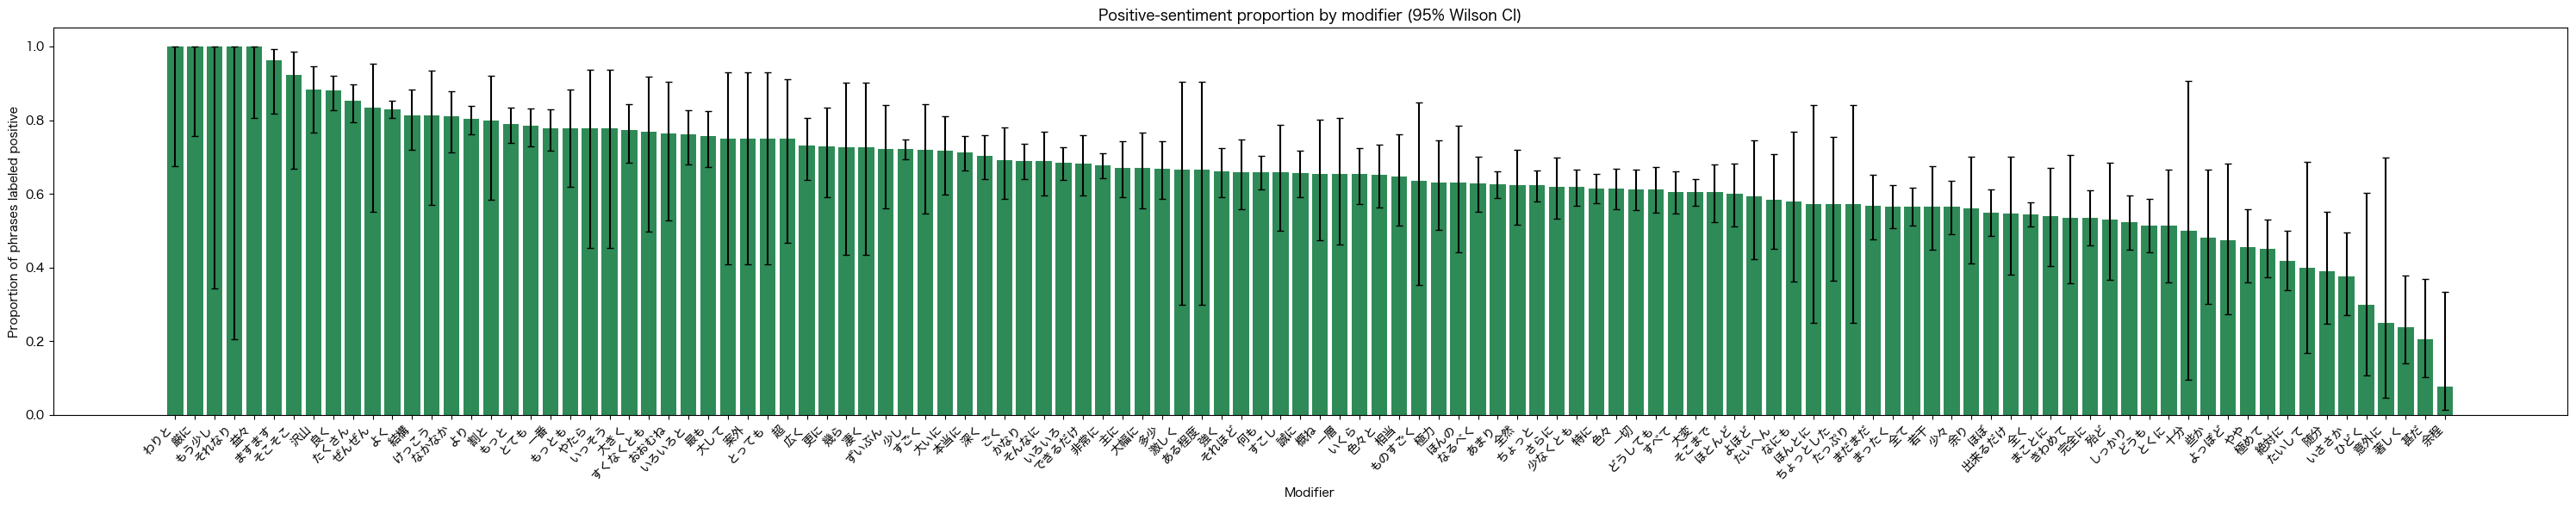

In [15]:
import matplotlib.pyplot as plot
import matplotlib.font_manager as fm
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

# --- Font setup for Japanese text ---
japanese_fonts = ["Hiragino Sans", "Hiragino Maru Gothic Pro", "Yu Gothic", "Meiryo", "Noto Sans CJK JP"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
chosen_font = next((f for f in japanese_fonts if f in available_fonts), None)
if chosen_font:
    plot.rcParams["font.family"] = chosen_font
else:
    print("No Japanese font found in matplotlib's font list.")

df_scored_phrases = pd.read_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_filtered_results.csv"
)

sentiment_counts = pd.crosstab(df_scored_phrases["modifier"], df_scored_phrases["phrase_sentiment_label"])
totals = sentiment_counts.sum(axis=1)
positive_proportion = sentiment_counts["positive"] / totals

# Sort by total frequency, most common modifier first
sort_order = positive_proportion.sort_values(ascending=False).index
positive_proportion = positive_proportion.loc[sort_order]
totals = totals.loc[sort_order]
# Wilson confidence interval on the positive count
ci_lower, ci_upper = proportion_confint(
    count=sentiment_counts.loc[sort_order, "positive"],
    nobs=totals,
    method="wilson",
)

err_lower = (positive_proportion - ci_lower).clip(lower=0)
err_upper = (ci_upper - positive_proportion).clip(lower=0)

fig, ax = plot.subplots(figsize=(30, 6))
ax.bar(
    positive_proportion.index,
    positive_proportion.values,
    yerr=[err_lower.values, err_upper.values],
    capsize=3,
    color="seagreen",
)
ax.set_xticklabels(positive_proportion.index, rotation=45, ha="right")
ax.set_ylabel("Proportion of phrases labeled positive")
ax.set_xlabel("Modifier")
ax.set_title("Positive-sentiment proportion by modifier (95% Wilson CI)")
plot.tight_layout()
plot.show()

In [5]:
import spacy
import pandas as pd
from transformers import pipeline

en_df = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_robust_categorizing_filtered_results.csv")

nlp_en = spacy.load("en_core_web_sm")

CLAUSE_BOUNDARY_DEPS = {"advcl", "ccomp", "csubj", "ROOT"}

# nlptown/bert-base-multilingual-uncased-sentiment:
# BERT-base, fine-tuned on Amazon-style product reviews (same domain as
# MARC-ja), outputs 1-5 stars. Collapsed below to positive/negative to
# match the JP pipeline's output schema.
sentiment_pipeline_en = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment",
    tokenizer="nlptown/bert-base-multilingual-uncased-sentiment",
)


def stars_to_binary_label(label):
    """Collapse nlptown's '1 star'..'5 stars' output to positive/negative,
    matching marc_ja's binary schema. 3 stars (neutral) is dropped."""
    n_stars = int(label[0])
    if n_stars <= 2:
        return "negative"
    if n_stars >= 4:
        return "positive"
    return None  # 3 stars: treated as neutral/ambiguous, not forced into binary


def is_target_negated_en(doc, target_index):
    """Checks whether a negation modifier ('not'/'n't') is a direct child
    of the target token. spaCy's English parser labels these dep_='neg'."""
    target_token = doc[target_index]
    for child in target_token.children:
        if child.dep_ == "neg":
            return True
    return False


def find_clause_head(token):
    """Climb the dependency tree from `token` up to the predicate governing
    the clause it sits in, stopping at the first clause boundary so the
    phrase doesn't extend into an outer clause."""
    current = token
    while current.dep_ not in CLAUSE_BOUNDARY_DEPS:
        if current.head == current:  # safety: already at the root
            break
        current = current.head
    return current


def extract_modifier_phrase_en(sentence, modifier):
    doc = nlp_en(sentence)
    tokens = [t.text.lower() for t in doc]
    modifier_tokens = [t.text.lower() for t in nlp_en(modifier)]
    modifier_len = len(modifier_tokens)

    for i in range(len(tokens) - modifier_len + 1):
        if tokens[i:i + modifier_len] == modifier_tokens:
            first_token = doc[i]
            head = first_token.head
            if head.text.lower() in modifier_tokens:
                return None

            negated = is_target_negated_en(doc, head.i)
            clause_head = find_clause_head(head)

            last_modifier_token = doc[i + modifier_len - 1]
            start_char = last_modifier_token.idx + len(last_modifier_token.text)
            end_char = clause_head.idx + len(clause_head.text)
            phrase = sentence[start_char:end_char].strip()

            return {
                "sentence": sentence,
                "modifier": modifier,
                "modifier_pos": first_token.pos_,
                "dep_relation": first_token.dep_,
                "target": head.text,
                "target_pos": head.pos_,
                "target_lemma": head.lemma_,
                "negated": negated,
                "phrase": phrase,
            }
    return None


def score_phrase_sentiment_en(phrase):
    if not phrase:
        return None, None
    result = sentiment_pipeline_en(phrase)[0]
    binary_label = stars_to_binary_label(result["label"])
    return binary_label, result["score"]
print("starting result processing")

results = []
for i, (modifier, sentence) in enumerate(en_df[['modifier', 'sentence']].values):
    result = extract_modifier_phrase_en(sentence, modifier)
    if result is None:
        result = {
            "sentence": sentence, "modifier": modifier, "modifier_pos": None,
            "dep_relation": None, "target": None, "target_pos": None,
            "target_lemma": None, "negated": None, "phrase": None,
        }
    label, score = score_phrase_sentiment_en(result.get("phrase"))
    result["phrase_sentiment_label"] = label
    result["phrase_sentiment_score"] = score
    results.append(result)

    if i % 100 == 0:
        print(f"Processed {i} rows")

pd.DataFrame(results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_robust_categorizing_results.csv",
    index=False,
)

filtered_results = [
    {
        "modifier": r["modifier"],
        "negated": r["negated"],
        "target": r["target"],
        "phrase": r["phrase"],
        "phrase_sentiment_label": r["phrase_sentiment_label"],
        "phrase_sentiment_score": r["phrase_sentiment_score"],
        "sentence": r["sentence"],
    }
    for r in results
]
pd.DataFrame(filtered_results).to_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_robust_categorizing_filtered_results.csv",
    index=False,
)

Device set to use mps:0


starting result processing
Processed 0 rows
Processed 100 rows
Processed 200 rows
Processed 300 rows
Processed 400 rows
Processed 500 rows
Processed 600 rows
Processed 700 rows
Processed 800 rows
Processed 900 rows
Processed 1000 rows
Processed 1100 rows
Processed 1200 rows
Processed 1300 rows
Processed 1400 rows
Processed 1500 rows
Processed 1600 rows
Processed 1700 rows
Processed 1800 rows
Processed 1900 rows
Processed 2000 rows
Processed 2100 rows
Processed 2200 rows
Processed 2300 rows
Processed 2400 rows
Processed 2500 rows
Processed 2600 rows
Processed 2700 rows
Processed 2800 rows
Processed 2900 rows
Processed 3000 rows
Processed 3100 rows
Processed 3200 rows
Processed 3300 rows
Processed 3400 rows
Processed 3500 rows
Processed 3600 rows
Processed 3700 rows
Processed 3800 rows
Processed 3900 rows
Processed 4000 rows
Processed 4100 rows
Processed 4200 rows
Processed 4300 rows
Processed 4400 rows
Processed 4500 rows
Processed 4600 rows
Processed 4700 rows
Processed 4800 rows
Proce

/var/folders/r5/f8zs_sx50gzg0thbjq84lpn80000gn/T/ipykernel_18088/2235351303.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(positive_proportion.index, rotation=45, ha="right")


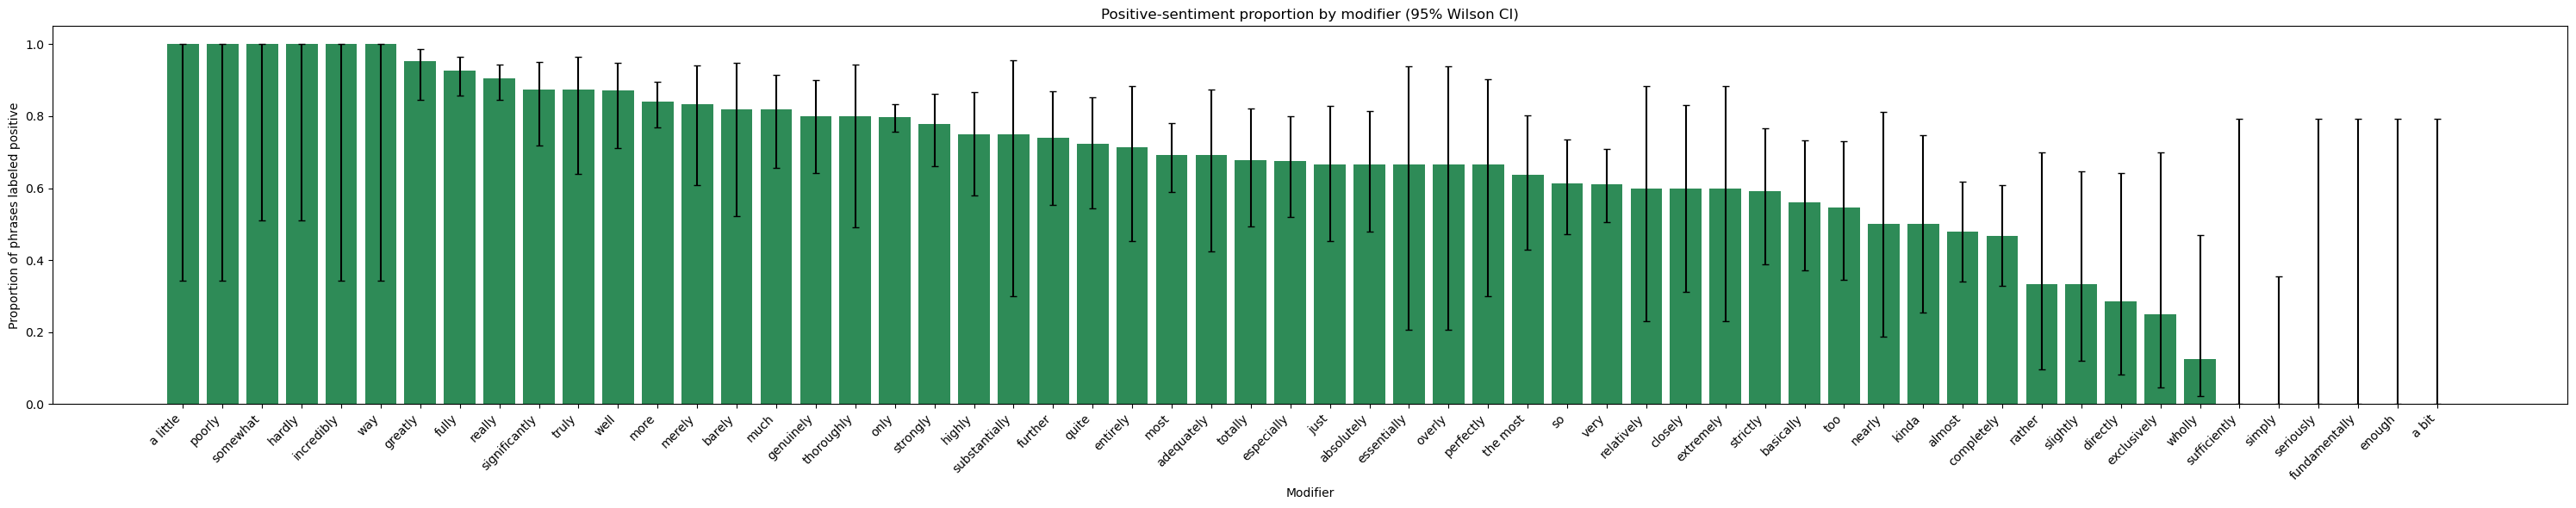

In [ ]:
import matplotlib.pyplot as plot
import matplotlib.font_manager as fm
import pandas as pd
from statsmodels.stats.proportion import proportion_confint

df_scored_phrases = pd.read_csv(
    "/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_robust_categorizing_filtered_results.csv"
)

sentiment_counts = pd.crosstab(df_scored_phrases["modifier"], df_scored_phrases["phrase_sentiment_label"])
totals = sentiment_counts.sum(axis=1)
positive_proportion = sentiment_counts["positive"] / totals

# Sort by total frequency, most common modifier first
sort_order = positive_proportion.sort_values(ascending=False).index
positive_proportion = positive_proportion.loc[sort_order]
totals = totals.loc[sort_order]
# Wilson confidence interval on the positive count
ci_lower, ci_upper = proportion_confint(
    count=sentiment_counts.loc[sort_order, "positive"],
    nobs=totals,
    method="wilson",
)

err_lower = (positive_proportion - ci_lower).clip(lower=0)
err_upper = (ci_upper - positive_proportion).clip(lower=0)

fig, ax = plot.subplots(figsize=(30, 6))
ax.bar(
    positive_proportion.index,
    positive_proportion.values,
    yerr=[err_lower.values, err_upper.values],
    capsize=3,
    color="seagreen",
)
ax.set_xticklabels(positive_proportion.index, rotation=45, ha="right")
ax.set_ylabel("Proportion of phrases labeled positive")
ax.set_xlabel("Modifier")
ax.set_title("Positive-sentiment proportion by modifier (95% Wilson CI)")
plot.tight_layout()
plot.show()

In [8]:
import numpy as np
import pandas as pd
from statsmodels.stats.meta_analysis import combine_effects
en_scored = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/en_robust_categorizing_filtered_results.csv")
jp_scored = pd.read_csv("/Users/yuka/Documents/Academics/Stanford/Research/crossCulturalPoliteness/comparingCulturesPolitenessLLM/finalized_pipeline/data/results/jp_robust_categorizing_filtered_results.csv")

def freeman_tukey_transform(x, n):
    """Double-arcsine transform of a proportion x/n. Its variance depends
    only on n, not on the proportion itself -- exactly the 'known,
    sample-size-dependent measurement variance' a meta-analysis needs."""
    theta = 0.5 * (np.arcsin(np.sqrt(x / (n + 1))) + np.arcsin(np.sqrt((x + 1) / (n + 1))))
    var_theta = 1 / (4 * n + 2)
    return theta, var_theta


def inter_modifier_heterogeneity(counts, totals, label="positive"):
    """
    Returns:
      tau2 -- estimated TRUE between-modifier variance (sampling noise
              subtracted out), on the arcsine scale
      i2   -- % of total observed variation attributable to true
              between-modifier differences rather than sampling noise
    """
    x = counts[label].reindex(totals.index).fillna(0).values.astype(float)
    n = totals.values.astype(float)

    theta, var_theta = freeman_tukey_transform(x, n)

    res = combine_effects(theta, var_theta, method_re="dl")
    tau2 = res.tau2

    # Cochran's Q, computed directly rather than relying on an
    # unconfirmed attribute name on the results object
    w = 1 / var_theta
    theta_bar_fixed = np.sum(w * theta) / np.sum(w)
    q_stat = np.sum(w * (theta - theta_bar_fixed) ** 2)
    k = len(theta)
    i2 = max(0.0, (q_stat - (k - 1)) / q_stat) * 100 if q_stat > 0 else 0.0

    return tau2, i2


# --- Apply to each language ---
en_counts = pd.crosstab(en_scored["modifier"], en_scored["phrase_sentiment_label"])
en_totals = en_counts.sum(axis=1)

jp_counts = pd.crosstab(jp_scored["modifier"], jp_scored["phrase_sentiment_label"])
jp_totals = jp_counts.sum(axis=1)

tau2_en, i2_en = inter_modifier_heterogeneity(en_counts, en_totals)
tau2_jp, i2_jp = inter_modifier_heterogeneity(jp_counts, jp_totals)

print(f"English:  tau^2 = {tau2_en:.5f},  I^2 = {i2_en:.1f}%")
print(f"Japanese: tau^2 = {tau2_jp:.5f},  I^2 = {i2_jp:.1f}%")


# --- Bootstrap: is tau^2_EN - tau^2_JP significantly different from 0? ---
def bootstrap_tau2_diff(en_counts, en_totals, jp_counts, jp_totals, label="positive", n_boot=2000, seed=0):
    rng = np.random.default_rng(seed)
    en_modifiers = en_counts.index.values
    jp_modifiers = jp_counts.index.values

    diffs = np.empty(n_boot)
    for b in range(n_boot):
        en_sample = rng.choice(en_modifiers, size=len(en_modifiers), replace=True)
        jp_sample = rng.choice(jp_modifiers, size=len(jp_modifiers), replace=True)

        tau2_en_b, _ = inter_modifier_heterogeneity(en_counts.loc[en_sample], en_totals.loc[en_sample], label)
        tau2_jp_b, _ = inter_modifier_heterogeneity(jp_counts.loc[jp_sample], jp_totals.loc[jp_sample], label)
        diffs[b] = tau2_en_b - tau2_jp_b

    return diffs

diffs = bootstrap_tau2_diff(en_counts, en_totals, jp_counts, jp_totals, n_boot=10000)
ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
print(f"Bootstrap 95% CI for tau^2_EN - tau^2_JP: [{ci_low:.5f}, {ci_high:.5f}]")
print(f"Proportion of bootstrap draws with EN > JP: {(diffs > 0).mean():.3f}")

English:  tau^2 = 0.02469,  I^2 = 74.7%
Japanese: tau^2 = 0.01201,  I^2 = 87.5%
Bootstrap 95% CI for tau^2_EN - tau^2_JP: [-0.00081, 0.02889]
Proportion of bootstrap draws with EN > JP: 0.966


In [13]:
# print english and japanese modifiers
print(en_scored['modifier'].unique())
print(jp_scored['modifier'].unique())

['rather' 'more' 'most' 'only' 'in any way' 'completely' 'strictly'
 'entirely' 'fully' 'fundamentally' 'very' 'much' 'further' 'the most'
 'nearly' 'strongly' 'especially' 'truly' 'quite' 'substantially' 'merely'
 'somewhat' 'a bit' 'too' 'relatively' 'really' 'kinda' 'essentially'
 'a little' 'almost' 'so' 'at all' 'significantly' 'closely' 'just'
 'simply' 'enough' 'well' 'thoroughly' 'extremely' 'wholly' 'slightly'
 'totally' 'genuinely' 'in detail' 'highly' 'hardly' 'overly' 'way'
 'sort of' 'absolutely' 'directly' 'basically' 'perfectly' 'adequately'
 'incredibly' 'exclusively' 'in full' 'sufficiently' 'poorly' 'greatly'
 'kind of' 'barely' 'seriously' 'a little bit']
['全て' 'より' '全く' '色々' 'そこまで' 'ちょっと' '色々と' 'いろいろ' '大いに' '最も' 'よく' '少し' 'かなり'
 'それほど' 'もっと' 'たくさん' 'まったく' '非常に' '特に' '更に' 'ほとんど' '極めて' 'どうも' 'できるだけ'
 'きわめて' '強く' '誠に' 'おおむね' '大変' '著しく' 'すべて' '良く' '本当に' '広く' '少なくとも' '一番'
 'これ以上' '絶対に' '一切' '十分' '若干' '何も' '主に' 'なるべく' 'やや' 'もう少し' '殆ど' '全然' 'なかなか'
 '少々' 'しっかり' 'あまり' '甚だ' '